<a href="https://colab.research.google.com/github/StereoWings7/potential-octo-giggle/blob/main/torch_ocr_UL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F #
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import torch.optim as optim
from torchvision import transforms
import kagglehub
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [2]:
os.chdir("/content/drive/MyDrive/Colab Notebooks")
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks'

In [3]:
path = kagglehub.dataset_download("harieh/ocr-dataset")

100%|██████████| 153M/153M [00:02<00:00, 76.5MB/s]

Extracting files...


In [4]:
print("Path to dataset files:", path)
data_dir = os.path.join(path,"dataset")

Path to dataset files: /root/.cache/kagglehub/datasets/harieh/ocr-dataset/versions/1


In [34]:
#別途計算した平均分散を元に正規化
mean = (0.912,)
std = (0.068,)
WIDTH=96 #元画像は小さいので拡大しておく
HEIGHT=96
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # グレースケール化
    transforms.Resize((WIDTH,HEIGHT)),  # サイズを統一
    transforms.ToTensor(),  # Tensorに変換 (形状: [1, H, W])
    transforms.Normalize(mean,std)
])

In [35]:
#画像データをImageFolderを使って取込みする
dataset = ImageFolder(data_dir, transform = train_transform)

In [36]:
# データセットを学習用(train)と検証用(val)に分割
train_ratio = 0.8  # 学習データの割合
train_size = int(train_ratio * len(dataset))  # 学習データのサイズを計算
val_size = len(dataset) - train_size  # 検証データのサイズを計算
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])  # ランダムに分割

In [37]:
# DataLoaderを作成（ミニバッチ学習のために使用）
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # 学習用（シャッフル有り）
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)  # 検証用（シャッフル無し）

In [30]:
# シンプルなCNNモデルの定義(
# ここではconv層2つとしたが、試してみたところもっとシンプルなconv層1つのモデルの方が性能でそう
# (今回学習させてるモデルは小さいので、複雑なモデルは過学習しそう)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes,conv_channels=(32,64)): # チャネル数をタプルで与えること
        super(SimpleCNN, self).__init__()
        conv1_channels, conv2_channels = conv_channels  # タプルからチャネル数を展開
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, conv1_channels, kernel_size=3, stride=1, padding=1),  # チャネル数は1 → conv1_channels
            nn.BatchNorm2d(conv1_channels), #バッチ正則化
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # ストライド2なので画像サイズは半分に。96 → 48

            nn.Conv2d(conv1_channels, conv2_channels, kernel_size=3, stride=1, padding=1),  # チャネル数はconv1 → conv2
            nn.BatchNorm2d(conv2_channels),#バッチ正則化 同上
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # ストライド2なので画像サイズは半分に。 48 → 24
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(conv2_channels * (WIDTH // 4) * (HEIGHT // 4), 128),  # conv2_channels x 24 x 24 → 128
            nn.ReLU(),
            nn.Dropout(0.4),  # ★ 過学習防止
            nn.Linear(128, num_classes)  # 出力層
        )

    def forward(self, x):
        x = self.conv_layers(x)  # 畳み込み層を通す
        x = x.view(x.size(0), -1)  # 平坦化
        x = self.fc_layers(x)  # 全結合層を通す
        return x

In [10]:
# デバイス設定（GPUが利用可能ならGPUを使用、そうでなければCPUを使用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
print(device)

cuda


In [39]:
# モデルのインスタンス化
num_classes = len(dataset.classes)  # クラス数を取得
model = SimpleCNN(num_classes=num_classes, conv_channels=(32, 64)).to(device)  # モデルをデバイス（GPU/CPU）に転送

In [40]:
# 損失関数と最適化手法の定義
criterion = nn.CrossEntropyLoss()  # 損失関数（クロスエントロピー）
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adamオプティマイザ（学習率0.001）

In [46]:
num_epochs = 3  # エポック数
for epoch in range(num_epochs):
    # ======== 学習フェーズ (Training Phase) ========
    model.train()  # モデルを学習モードに設定
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:  # 学習データの各ミニバッチ処理
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # 勾配の初期化
        outputs = model(images)  # 順伝播（予測）
        loss = criterion(outputs, labels)  # 損失計算
        loss.backward()  # 逆伝播（勾配計算）
        optimizer.step()  # 最適化（パラメータ更新）

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = correct_train / total_train  # 訓練データの精度を計算

    # ======== 検証フェーズ (Validation Phase) ========
    model.eval()  # 検証モード
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # 勾配計算を無効化
        for val_images, val_labels in val_loader:  # 検証データの全ミニバッチ処理
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            _, val_predicted = torch.max(val_outputs, 1)
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_acc = correct_val / total_val  # 検証データの精度

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, "
          f"Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}")


Epoch 1/3, Loss: 0.5838, Train Accuracy: 0.8364, Val Accuracy: 0.8807
Epoch 2/3, Loss: 0.5458, Train Accuracy: 0.8453, Val Accuracy: 0.8836
Epoch 3/3, Loss: 0.5161, Train Accuracy: 0.8521, Val Accuracy: 0.8913


In [48]:
# テストフェーズ (Test Phase) - 全データを対象に評価
model.eval()  # モデルを評価モードに設定
y_true = []  # 正解ラベルを保存するリスト
y_pred = []  # 予測ラベルを保存するリスト

with torch.no_grad():  # 勾配計算を無効化（メモリ節約）
    for images, labels in val_loader:  # テストデータ全体を処理 ほんとは専用のtest_loaderを準備すべき
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)  # モデルの予測
        _, predicted = torch.max(outputs, 1)  # 確率が最大のクラスを取得

        y_true.extend(labels.cpu().numpy())  # 正解ラベルを保存
        y_pred.extend(predicted.cpu().numpy())  # 予測ラベルを保存

Validation Accuracy: 0.8913


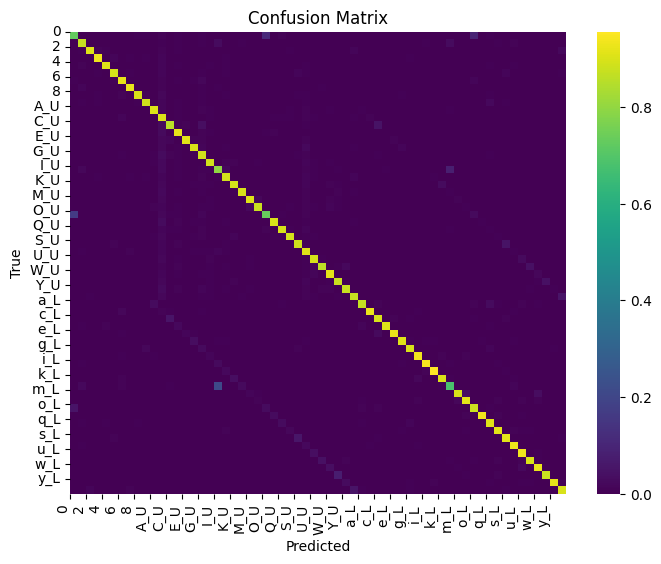

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
# 混同行列の計算
cm = confusion_matrix(y_true, y_pred)  # scikit-learn の confusion_matrix で評価
acc = accuracy_score(y_true, y_pred)  # scikit-learn の accuracy_score で精度計算
print(f"Validation Accuracy: {acc:.4f}")  # 検証データの精度を表示

# 各行ごとに正規化（行の合計で割る）
cm_percentage = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# 混同行列の可視化
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_percentage, annot=False, fmt="d", cmap="viridis", xticklabels=dataset.classes, yticklabels=dataset.classes)  # 混同行列のヒートマップを作成

# 目盛りの位置を取得
tick_positions = np.arange(0, len(dataset.classes), step=2)  # 2つおきに表示
tick_labels = np.array(dataset.classes)[tick_positions]  # 2つおきにラベルを取得

# X軸とY軸のラベルを設定
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha="right")

ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0)
plt.xlabel("Predicted",fontsize=10)  # x軸のラベル
plt.ylabel("True", fontsize=10)  # y軸のラベル
plt.title("Confusion Matrix",fontsize=12)  # グラフタイトル
plt.show()  # ヒートマップを表示

In [50]:
# 誤分類の多いクラスがどれかを調べる
# 対角要素を無視するため、対角成分を np.nan にする
cm_no_diag = cm_percentage.copy()
np.fill_diagonal(cm_no_diag, np.nan)  # 対角成分をNaNにする

# 上位5つの誤分類を取得
top_5_indices = np.dstack(np.unravel_index(np.argsort(-np.nan_to_num(cm_no_diag), axis=None), cm.shape))[0][:5]

# 結果を表示
print("対角成分以外で最も誤分類が多い5つの位置とその値:")
for row, col in top_5_indices:
    print(f"True Label: {dataset.classes[row]}, Predicted Label: {dataset.classes[col]}, Count: {cm[row, col]}")

対角成分以外で最も誤分類が多い5つの位置とその値:
True Label: l_L, Predicted Label: I_U, Count: 145
True Label: O_U, Predicted Label: 0, Count: 116
True Label: 0, Predicted Label: O_U, Count: 77
True Label: 0, Predicted Label: o_L, Count: 63
True Label: I_U, Predicted Label: l_L, Count: 56


以下はおまけ

In [42]:
# DataLoader のデバッグ
data_iter = iter(train_loader)  # データローダーから最初のバッチを取得
images, labels = next(data_iter)  # バッチの取得

print("データローダーのデバッグ:")
print(f"画像の形状: {images.shape}")  # (batch_size, 3, 128, 128) のはず
print(f"ラベルのサンプル: {labels}")  # ラベルがバッチごとに異なるか確認


データローダーのデバッグ:
画像の形状: torch.Size([32, 1, 96, 96])
ラベルのサンプル: tensor([42, 45, 58, 48, 43, 20, 41,  1, 14, 36,  7, 36,  1, 27, 29, 25, 59, 16,
        21, 44, 21, 33,  1, 14, 22, 22, 38,  9,  6, 16, 48, 46])


In [43]:
# 学習ループのデバッグ
model.train()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)  # モデルの出力
    print("出力の形状:", outputs.shape)  # (batch_size, num_classes) のはず
    print("出力のサンプル:", outputs[0])  # 最初のデータの出力確認
    print("正解ラベル:", labels[0])  # ラベル確認

    loss = criterion(outputs, labels)
    print("損失:", loss.item())  # 損失値確認
    break  # 最初のバッチだけ確認


出力の形状: torch.Size([32, 62])
出力のサンプル: tensor([ 0.2693, -0.5016,  0.4896,  0.1096,  0.3679,  0.0037, -0.0323, -0.4954,
        -0.2065, -0.0999, -0.3203, -0.0795, -0.1245,  0.1208,  0.3434, -0.3267,
        -0.0308, -0.1492, -0.0633,  0.2695,  0.3982, -0.4263,  0.1131,  0.5564,
        -0.3484,  0.0614,  0.1536,  0.3882,  0.1499, -0.1223, -0.0606,  0.3967,
        -0.5030, -0.3012,  0.2391,  0.3174, -0.2622,  0.1023, -0.0613,  0.0568,
         0.0205,  0.2865, -0.6145, -0.4753, -0.1244, -0.0829,  0.4003,  0.3909,
         0.1734,  0.2627,  0.0312,  0.0310, -0.0216, -0.1997,  0.2200,  0.0600,
         0.2877, -0.0079,  0.0517,  0.4216,  0.0916,  0.0456], device='cuda:0',
       grad_fn=<SelectBackward0>)
正解ラベル: tensor(58, device='cuda:0')
損失: 4.160347938537598


In [41]:
# モデルの単体テスト
dummy_input = torch.randn(1, 1, 96, 96).to(device)  # 1チャネルのグレースケール画像を作成
dummy_output = model(dummy_input)  # 順伝播
print("モデル出力の形状:", dummy_output.shape)  # (1, num_classes) のはず
print("モデル出力の値:", dummy_output)  # 数値が全てゼロになっていないか確認


モデル出力の形状: torch.Size([1, 62])
モデル出力の値: tensor([[-0.1685, -0.4589,  0.2151, -0.2378,  0.0649,  0.2778,  0.3755,  0.0682,
         -0.1633,  0.4066, -0.4046,  0.2229,  0.3340,  0.0171, -0.1543, -0.3408,
          0.4964, -0.2050, -0.6260,  0.3569,  0.2102, -0.0260,  0.3245,  0.2820,
         -0.2900,  0.0250,  0.1103, -0.6418,  0.5958, -0.0647, -0.1935,  0.3986,
         -0.1881, -0.4522,  0.0247, -0.1969,  0.5130, -0.4256,  0.1930, -0.3035,
         -0.2782,  0.3071, -0.4594,  0.2860, -0.3815, -0.6832,  0.1462,  0.4548,
         -0.1381,  0.4979, -0.0389,  0.0964, -0.2796, -0.3831, -0.2777, -0.1732,
          0.0050, -0.8094, -0.0333, -0.0695, -0.1313, -0.3303]],
       device='cuda:0', grad_fn=<AddmmBackward0>)
